In [13]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [14]:
def create_mask(hsv, image):
    """"Создаёт маску для цвета брёвен на изображении"""
    # Примерные диапазоны для светлого дерева в HSV
    light_wood_low = np.array([10, 60, 30])  
    light_wood_high = np.array([20, 255, 255])

    # Создание маски
    mask1 = cv.inRange(hsv, light_wood_low, light_wood_high)
    wood_mask = mask1

    kernel = np.ones((5,5), np.uint8)
    wood_mask = cv.morphologyEx(wood_mask, cv.MORPH_CLOSE, kernel)
    wood_mask = cv.morphologyEx(wood_mask, cv.MORPH_OPEN, kernel)

    wood_only = cv.bitwise_and(image, image, mask=wood_mask)

    plt.imshow(wood_only)

    return wood_only

In [ ]:
def draw_canny_edges(image_rgb, image_gray, threshold = 180):
    """"Отрисовывает границы на изображении с помощью метода Кэнни (для отладки)"""
    edges = cv.Canny(image_gray, threshold1=threshold/2, threshold2=threshold)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1) 
    plt.imshow(image_rgb)  
    plt.title('Оригинальное изображение')
    plt.axis('off')  

    plt.subplot(1, 2, 2)
    plt.imshow(edges, cmap='gray')
    plt.title('Границы (Canny edges)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [16]:
def draw_logs(image_rgb, detected_circles):
    """"Подсчитывает количество брёвен и отрисовывает их"""
    logs_count = 0
    if detected_circles is not None:
        detected_circles = np.uint16(np.around(detected_circles))

        for points in detected_circles[0, :]:
            a, b, r = points[0], points[1], points[2]

            cv.circle(image_rgb, (a, b), r, (0, 255, 0), 2)
            
            cv.circle(image_rgb, (a, b), 1, (255, 0, 0), 3)

            logs_count += 1

    print("Всего брёвен на изображении: ", logs_count)
    plt.imshow(image_rgb)

In [17]:
def count_logs(image_path, scale_coef):
    """"Основная функция для подсчёта брёвен"""
    image = cv.imread(image_path)
    image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB) 
    hsv = cv.cvtColor(image, cv.COLOR_BGR2HSV)

    wood_only = create_mask(hsv, image)

    gray = cv.cvtColor(wood_only, cv.COLOR_BGR2GRAY)
    gray = cv.blur(gray, (5, 5))
    plt.imshow(gray)

    draw_canny_edges(image_rgb, gray)

    detected_circles = cv.HoughCircles(gray,
                   cv.HOUGH_GRADIENT,
                   scale_coef,  # Inverse ratio of the accumulator resolution to the image resolution
                   55 * scale_coef, # Minimum distance between the centers of the detected circles
                   param1 = 180, # The higher threshold of the two passed to the Canny edge detector
                   param2 = 20,  # The accumulator threshold for the circle centers at the detection stage
                   minRadius = int(15 * scale_coef), maxRadius = int(80 * scale_coef))

    draw_logs(image_rgb, detected_circles)


# logs-1

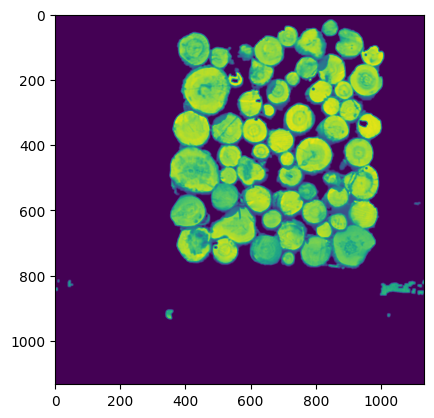

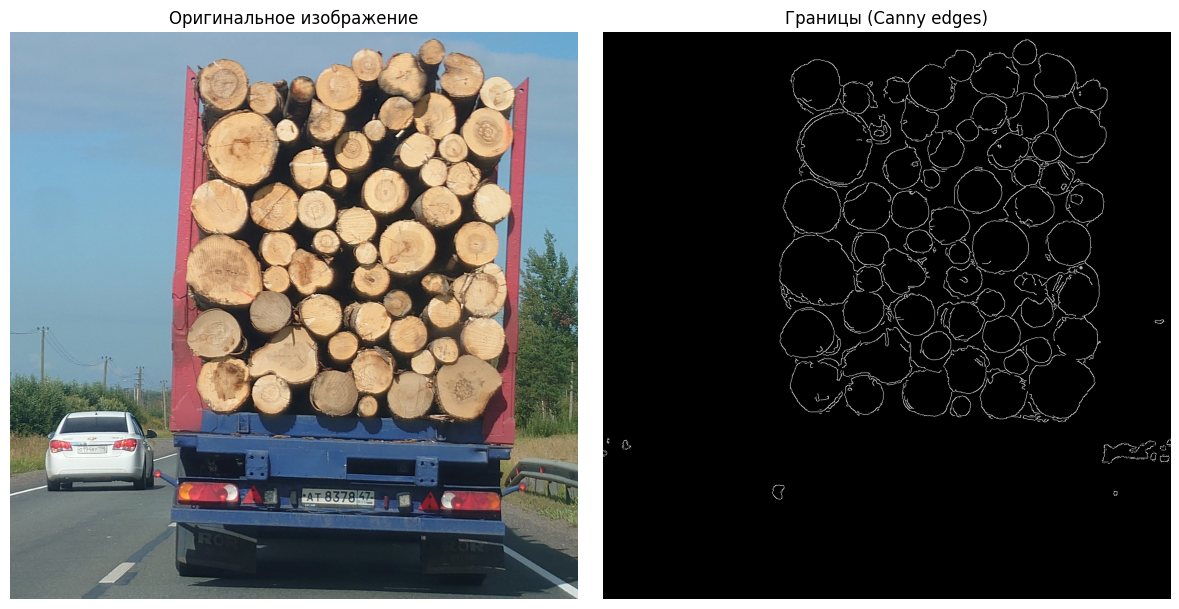

Всего брёвен на изображении:  60


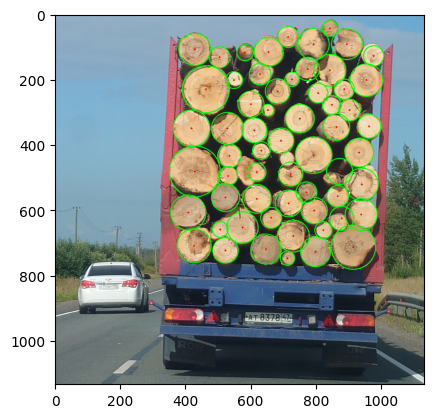

In [18]:
image_path = "images/logs-1.jpg"
count_logs(image_path, 1)

# logs-2

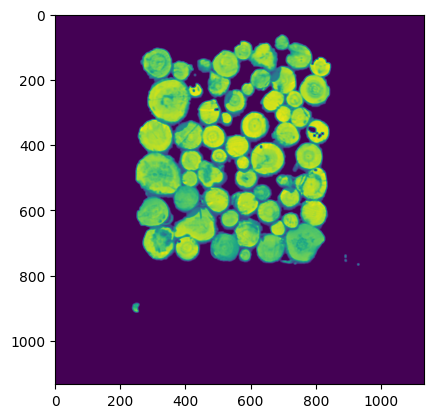

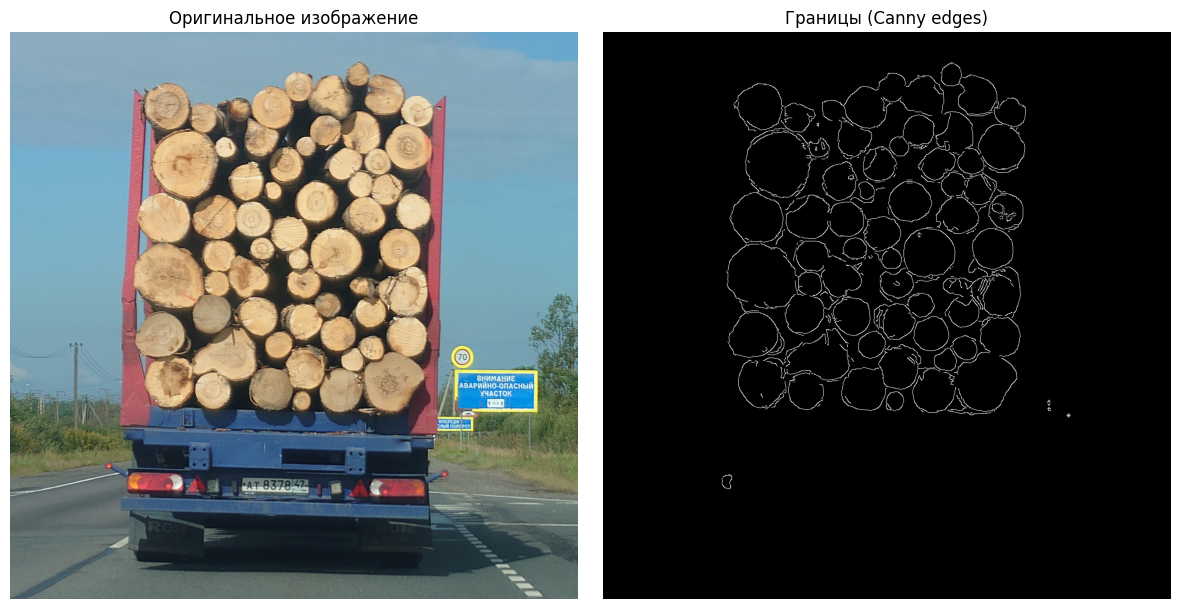

Всего брёвен на изображении:  56


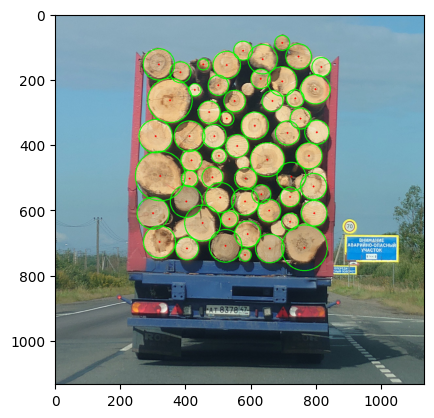

In [19]:
image_path = "images/logs-2.jpg"
count_logs(image_path, 1)

# logs-3

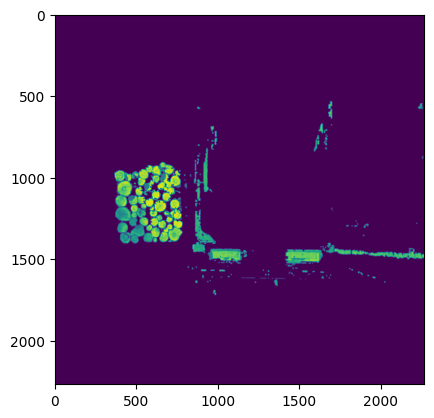

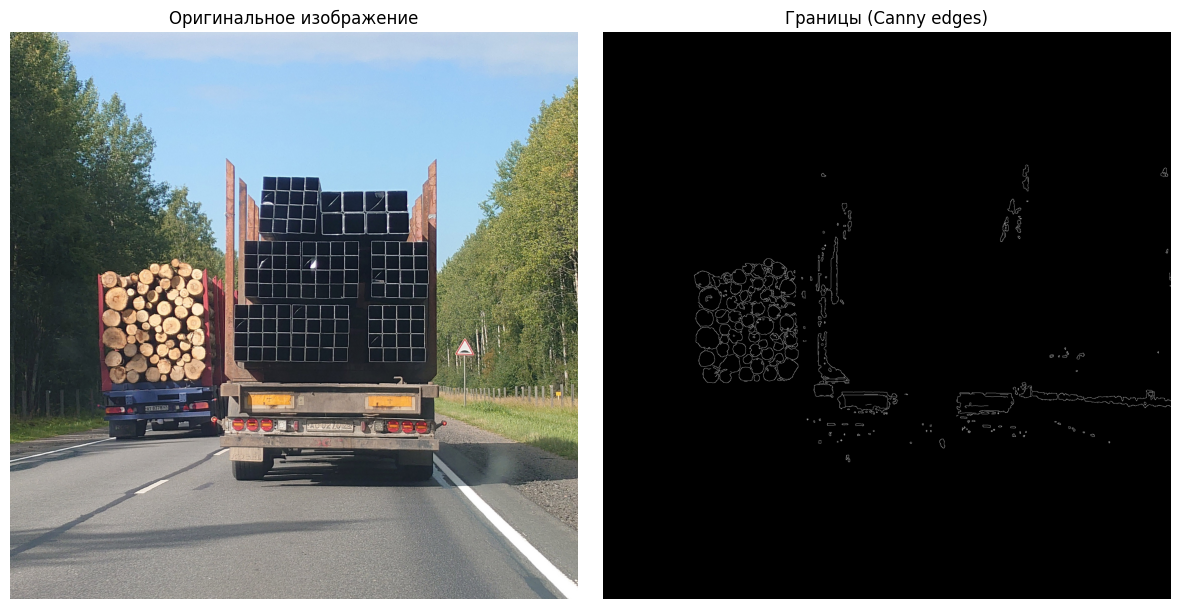

Всего брёвен на изображении:  52


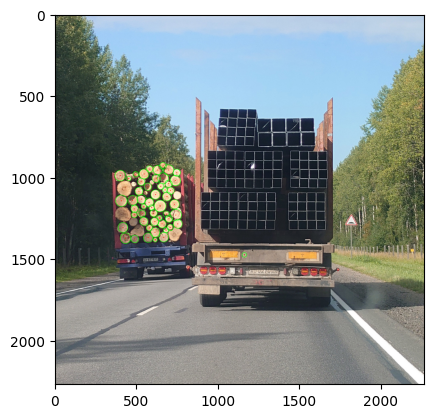

In [20]:
image_path = "images/logs-3.jpg"
count_logs(image_path, 0.5)